# Bayesian 기반 도로(차선 영역) 분류 예제

이 코드는 2026년 성신여자대학교 자율이동체시스템 수업에서 사용하기 위해 만든 코드입니다. KITTI 데이터셋의 흑백 이미지 프레임을 이용하여 도로 영역(road)과 배경(background)을 구분하는 간단한 Bayesian 분류기를 구현하였습니다. 복잡한 딥러닝 모델 없이도, 픽셀 밝기 분포와 확률 모델만으로 도로를 추정하는 기본적인 아이디어를 이해하는 데 목적이 있습니다.

## 1. 도로 검출

전체적인 동작 과정은 다음과 같습니다.

먼저, 이미지에서 도로가 존재할 가능성이 높은 영역을 사다리꼴 형태로 가정합니다. 이는 카메라 영상에서 도로가 아래쪽에서 넓고 위쪽으로 갈수록 좁아지며, 소실점 방향으로 수렴한다는 기하학적 특성을 이용한 것입니다. 이 영역은 도로 후보(road), 그 외 영역은 배경(background)으로 간주합니다.

그 다음, 각 프레임에 대해 도로 영역과 배경 영역에서 픽셀 밝기 히스토그램을 각각 계산합니다. 이 히스토그램은 “도로일 때 특정 밝기 값이 나올 확률”과 “배경일 때 특정 밝기 값이 나올 확률”을 근사하는 역할을 합니다. 이때 Laplace smoothing을 적용하여 확률이 0이 되는 문제를 방지합니다.

이후 Bayesian 분류 원리를 이용하여 각 픽셀에 대해 다음을 계산합니다.
  - 해당 픽셀이 도로일 확률
  - 해당 픽셀이 배경일 확률

두 값을 비교하여 더 큰 쪽으로 분류하면 MAP (Maximum A Posteriori) 기반 이진 마스크가 생성됩니다.

또한 이 코드는 단일 프레임만 사용하는 것이 아니라, 이전 프레임의 통계 정보를 일정 비율로 유지하면서 현재 프레임과 결합하는 방식으로 시계열 일관성(temporal consistency)을 반영합니다. 이를 통해 프레임 간 노이즈를 줄이고 더 안정적인 결과를 얻을 수 있습니다.

최종적으로 다음과 같은 결과를 생성합니다.
  - mask_XXXXXX.png : 도로(255) / 배경(0)으로 구성된 이진 마스크
  - overlay_XXXXXX.png : 원본 영상 위에 도로 영역을 빨간색으로 표시한 결과
  - prob_XXXXXX.png : 각 픽셀이 도로일 확률을 나타낸 그레이스케일 이미지

이 예제는 차선 검출이나 자율주행 인식에서 사용되는 복잡한 모델의 기초 개념을 이해하기 위한 출발점으로 활용할 수 있으며, 이후 Hough Transform, CNN 기반 segmentation 등으로 확장해 볼 수 있습니다.

In [1]:
"""
Minimal Bayesian road-vs-background classifier for KITTI grayscale frames.

Assumptions
-----------
- Images are KITTI odometry grayscale frames (image_0) sized 1241x376.
- Road pixels appear mostly in a bottom trapezoid; background near top band.
- Uses 1D intensity histograms with Laplace smoothing to estimate likelihoods.

Usage
-----
    --data-root dataset/sequences/00/image_0 \
    --train-frames 80 \
    --save-frames 10 \
    --out-dir outputs/bayes_road

Outputs
-------
- <out-dir>/mask_XXXXXX.png     : binary MAP mask (road=255, bg=0)
- <out-dir>/overlay_XXXXXX.png  : red overlay of road mask on original frame
- <out-dir>/prob_XXXXXX.png     : grayscale probability map (0-255)
"""
#!/usr/bin/env python3
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """
    소실점을 기준으로 도로 가능성이 높은 사다리꼴 마스크를 생성합니다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    
    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)
    
    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내의 픽셀만 사용하여 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    """Return MAP mask and probability map for road class."""
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):
    """
    alpha: 시계열 일관성 계수 (0.8이면 기존 지식 80%, 새 프레임 20% 반영)
    save_frames: -1 이면 모든 프레임 저장
    video_path: 지정 시 overlay 프레임을 영상으로 기록
    """
    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape
    
    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주
    
    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)
        
        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)
        
        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)
        
        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

import sys as _sys
if __name__ == "__main__" and "ipykernel" not in _sys.modules:
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-root", type=Path, default=Path("dataset/sequences/00/image_0"))
    parser.add_argument("--train-frames", type=int, default=80)
    parser.add_argument("--save-frames", type=int, default=10, help="frames to save; -1 for all")
    parser.add_argument("--out-dir", type=Path, default=Path("outputs/bayes_road_advanced"))
    parser.add_argument("--prior-road", type=float, default=0.5)
    parser.add_argument("--alpha", type=float, default=0.85, help="Temporal consistency weight")
    parser.add_argument("--video-path", type=Path, default=None, help="if set, write overlay video here")
    parser.add_argument("--video-fps", type=float, default=10.0)
    parser.add_argument("--vp-y-rate", type=float, default=0.5, help="vanishing point height ratio")
    parser.add_argument("--bottom-width-rate", type=float, default=0.9)
    parser.add_argument("--top-width-rate", type=float, default=0.15)
    parser.add_argument("--max-frames", type=int, default=None, help="process at most this many frames (after sorting)")
    parser.add_argument("--gif-path", type=Path, default=None, help="optional GIF output of overlays")
    parser.add_argument("--gif-fps", type=float, default=8.0)
    args = parser.parse_args()
    
    run(
        args.data_root,
        args.train_frames,
        args.save_frames,
        args.out_dir,
        args.prior_road,
        args.alpha,
        args.video_path,
        args.video_fps,
        args.vp_y_rate,
        args.bottom_width_rate,
        args.top_width_rate,
        args.max_frames,
        args.gif_path,
        args.gif_fps,
    )


이미지 폴더: D:\subin\kitti\dataset\sequences\09\image_0  (총 1591 프레임)
Processed 000000 with temporal consistency
Processed 000001 with temporal consistency
Processed 000002 with temporal consistency
Processed 000003 with temporal consistency
Processed 000004 with temporal consistency
Processed 000005 with temporal consistency
Processed 000006 with temporal consistency
Processed 000007 with temporal consistency
Processed 000008 with temporal consistency
Processed 000009 with temporal consistency
Processed 000010 with temporal consistency
Processed 000011 with temporal consistency
Processed 000012 with temporal consistency
Processed 000013 with temporal consistency
Processed 000014 with temporal consistency
Processed 000015 with temporal consistency
Processed 000016 with temporal consistency
Processed 000017 with temporal consistency
Processed 000018 with temporal consistency
Processed 000019 with temporal consistency
Processed 000020 with temporal consistency
Processed 000021 with temporal 

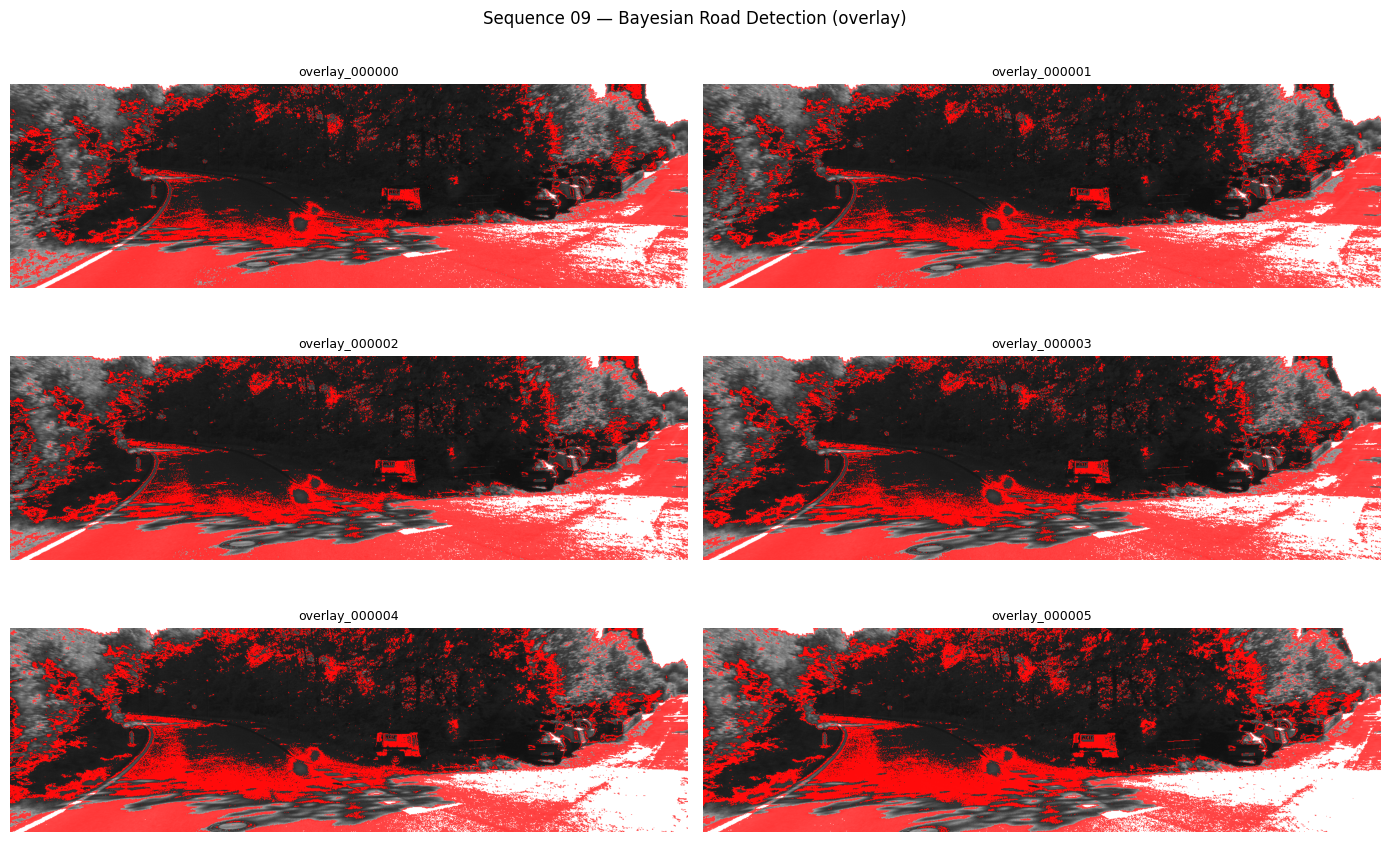

In [2]:
# === 시퀀스 09에서 베이지안 도로 분류기 실행 + 결과 시각화 ===
# 이 셀은 위 셀에서 정의된 run() 함수를 사용하여 KITTI sequence 09에 분류기를 적용합니다.
# 결과는 matplotlib로 노트북에 inline 출력되므로 GitHub에서도 그대로 보입니다.

from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# --- 경로 설정 (본인 환경) ---
KITTI_ROOT = Path(r"D:\subin\kitti\dataset")
SEQ        = "09"
DATA_ROOT  = KITTI_ROOT / "sequences" / SEQ / "image_0"
OUT_DIR    = Path("output") / f"bayes_road_seq{SEQ}"

assert DATA_ROOT.exists(), f"이미지 폴더가 없음: {DATA_ROOT}"
print(f"이미지 폴더: {DATA_ROOT}  (총 {len(list(DATA_ROOT.glob('*.png')))} 프레임)")

# --- 분류기 실행 ---
# 시간 절약을 위해 처음 30프레임만 처리. 전체 돌리려면 max_frames=None.
run(
    data_root=DATA_ROOT,
    train_frames=80,
    save_frames=30,
    out_dir=OUT_DIR,
    prior_road=0.5,
    alpha=0.85,
    max_frames=30,
)

# --- 결과 시각화 (overlay 6장) ---
overlay_files = sorted(OUT_DIR.glob("overlay_*.png"))[:6]
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for ax, p in zip(axes.flat, overlay_files):
    ax.imshow(np.array(Image.open(p)))
    ax.set_title(p.stem, fontsize=9)
    ax.axis("off")
plt.suptitle(f"Sequence {SEQ} — Bayesian Road Detection (overlay)", fontsize=12)
plt.tight_layout()
plt.show()


## 2. 차선 검출

이제 수업 시간에 배운 차선 검출을 중간고사 대체 과제로 진행합니다. 중간고사 대체 과제는 다음과 같습니다. 단, 본 과제는 반드시 sequences 09를 사용해야 합니다.

문제 1. Projection Matrix 해석

이 행렬이 어떤 의미를 가지는지 설명하고, 다음을 포함하여 해석하시오.
  - intrinsic 파라미터 (f_x, f_y, c_x, c_y)의 의미
  - extrinsic 파라미터 (R, t)의 역할
  - 이 행렬이 3D 점을 이미지 좌표로 어떻게 변환하는지 수식으로 설명

⸻

문제 2. Projection Matrix를 이용한 3D → 2D 투영

임의의 3차원 점들을 생성하고, projection matrix를 이용하여 이미지 좌표로 투영하시오.

투영된 점들을 이미지 위에 시각화하고, 결과가 카메라 투영의 특성과 어떻게 일치하는지 설명하시오.

⸻

문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 데이터를 이용하여 1번 카메라(차량)의 이동 궤적을 시각화하시오.
  - 각 프레임의 카메라 위치를 추출하여 2D 또는 3D로 표현
  - 초기 프레임을 기준 좌표계로 설정
  - 차량의 이동 방향과 속도에 대해 간단히 설명

⸻

문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과로 얻은 도로 영역을 이용하여 차선 후보를 추출하고, 이를 projection matrix와 연관 지어 해석하시오.

다음 내용을 포함하시오.
	•	이미지 좌표에서 검출된 차선이 카메라 좌표계에서 어떤 의미를 가지는지 설명
	•	도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성 설명
	•	projection matrix가 차선의 기울기, 소실점(vanishing point)과 어떤 관계가 있는지 설명

⸻

문제 5. 실패 구간 분석

차량 궤적 중에서 차선 분류가 잘 되지 않은 구간을 1개 이상 선택하시오.

다음을 수행하시오.
	•	해당 구간의 프레임 번호를 제시
	•	궤적 상에서 해당 위치를 표시
	•	왜 분류가 잘 되지 않았는지 설명

설명에는 다음 요소를 포함할 것.
	•	조명 변화 또는 그림자
	•	도로 질감 변화
	•	차량의 회전 또는 경사
	•	ROI(사다리꼴 가정)의 한계

⸻

문제 6. 딥리서치 등을 활용해 차선 검출을 위한 딥러닝 모델을 찾아 하나를 제안하고, 적용한 결과를 비교하여 보이시오.

---

## 문제 1 풀이 — Projection Matrix 해석

### 1) Projection Matrix란?

3차원 세계 좌표(World coordinate)에 있는 점 $P_w = (X, Y, Z)$를 2차원 이미지 평면의 픽셀 좌표 $(u, v)$로 변환하는 $3 \times 4$ 행렬이다.

$$
P = K \, [R \mid t]
$$

여기서:
- $K$ : **intrinsic (내부 파라미터)** — 카메라 자체의 광학적 특성
- $[R \mid t]$ : **extrinsic (외부 파라미터)** — 카메라가 세계 좌표계에서 어디에 어떻게 놓였는지

### 2) Intrinsic 파라미터의 의미

$$
K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}
$$

- $f_x, f_y$ : **초점거리(focal length)** — 픽셀 단위. 렌즈 초점거리(mm)와 픽셀 크기로 결정. 큰 값일수록 좁은 화각(망원), 작을수록 넓은 화각(광각).
- $c_x, c_y$ : **주점(principal point)** — 광축이 이미지 평면을 만나는 픽셀 좌표. 이상적으로는 이미지 중심이지만, 실제 센서 정렬 오차로 약간 벗어남.

### 3) Extrinsic 파라미터의 의미

- $R$ ($3 \times 3$ 회전행렬) — 카메라의 **방향**. 월드 좌표축을 카메라 좌표축으로 회전시키는 변환.
- $t$ ($3 \times 1$ 이동벡터) — 카메라의 **위치**. 월드 원점을 카메라 좌표계에서 본 위치.

→ 둘이 합쳐서 "월드 좌표 → 카메라 좌표" 강체변환을 정의한다.

### 4) 3D → 2D 변환 수식

월드 좌표 $(X, Y, Z, 1)^T$를 동차좌표(homogeneous)로 표현하면:

$$
s \begin{bmatrix} u \\ v \\ 1 \end{bmatrix}
= K \, [R \mid t] \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}
= P \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}
$$

여기서 $s$는 카메라 좌표계에서의 깊이(depth) $Z_c$이다. 마지막에 $s$로 나눠주는(=동차좌표 정규화) 단계가 바로 원근 투영(perspective projection)의 본질이다 — 가까운 물체는 크게, 먼 물체는 작게 보이게 만드는 효과.

KITTI는 카메라 P0을 기준 좌표계로 잡기 때문에, 우리가 사용하는 P0의 경우 $R = I$, $t = 0$이며 $P_0 = [K \mid 0]$ 형태가 된다. 다른 카메라(P1, P2, P3)의 P 행렬은 P0 기준의 baseline만큼 $t$가 들어있다.


In [5]:
# === 문제 1: 시퀀스 09의 calib.txt 파싱 후 K, R, t 분해 ===
import numpy as np
from pathlib import Path

CALIB_PATH = Path(r"D:\subin\kitti\dataset\sequences\09\calib.txt")

def load_kitti_calib(path):
    """KITTI calib.txt 파일을 읽어 P0~P3을 dict로 반환."""
    calib = {}
    with open(path) as f:
        for line in f:
            key, *vals = line.strip().split()
            if not key.endswith(":"):
                continue
            P = np.array(vals, dtype=np.float64).reshape(3, 4)
            calib[key[:-1]] = P
    return calib

calib = load_kitti_calib(CALIB_PATH)
P0 = calib["P0"]   # 왼쪽 grayscale 카메라 (image_0이 사용하는 카메라)

print("=== P0 (3x4 projection matrix) ===")
print(P0)

# K | [R t] 분해 (P0의 경우 R=I, t=0이라 단순 분해 가능)
K = P0[:, :3]
Rt = np.linalg.inv(K) @ P0      # 3x4
R  = Rt[:, :3]
t  = Rt[:,  3]

print("\n=== K (intrinsic) ===")
print(K)
print(f"\nfx = {K[0,0]:.4f}, fy = {K[1,1]:.4f}")
print(f"cx = {K[0,2]:.4f}, cy = {K[1,2]:.4f}")

print("\n=== R (rotation, P0 기준이므로 단위행렬) ===")
print(R)

print("\n=== t (translation, P0 기준이므로 영벡터) ===")
print(t)

# 다른 카메라들의 baseline 비교
print("\n=== 다른 카메라들의 baseline (t벡터) ===")
for name in ["P1", "P2", "P3"]:
    P = calib[name]
    Rt_n = np.linalg.inv(K) @ P
    print(f"  {name} t = {Rt_n[:,3]}")


=== P0 (3x4 projection matrix) ===
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]

=== K (intrinsic) ===
[[707.0912   0.     601.8873]
 [  0.     707.0912 183.1104]
 [  0.       0.       1.    ]]

fx = 707.0912, fy = 707.0912
cx = 601.8873, cy = 183.1104

=== R (rotation, P0 기준이므로 단위행렬) ===
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

=== t (translation, P0 기준이므로 영벡터) ===
[0. 0. 0.]

=== 다른 카메라들의 baseline (t벡터) ===
  P1 t = [-0.53715065  0.          0.        ]
  P2 t = [ 0.06103058 -0.00143972  0.00620322]
  P3 t = [-0.47441838  0.00187031  0.0033185 ]


---

## 문제 2 풀이 — 3D → 2D 투영

### 접근 방법

KITTI 카메라 좌표계는 다음과 같이 정의된다:
- $X$ : 오른쪽
- $Y$ : 아래쪽
- $Z$ : 전방 (광축 방향)

카메라는 차량 지붕에 약 1.65 m 높이로 부착되어 있으므로, **지면(ground plane)은 $Y = 1.65$** 이다.

세 가지 종류의 3D 점을 만들어 P0으로 투영해 본다:

1. **지면 위 격자** — $Y = 1.65$ 평면 위에 $X \in [-5, 5]$, $Z \in [5, 50]$ 격자 (perspective foreshortening 확인용)
2. **차선 모사 직선** — $X = \pm 1.85$ (차선 폭 절반), $Z$가 변하는 평행한 두 직선 (소실점에서 만나는 거 확인용)
3. **수직 기둥** — 다양한 $Z$에서 높이 2 m 짜리 수직 막대 (멀수록 작아 보임 확인용)

투영 수식:
$$
\begin{bmatrix} u' \\ v' \\ w' \end{bmatrix} = P_0 \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}, \quad
u = u'/w', \quad v = v'/w'
$$

여기서 $w' = Z$ (깊이)이며, 이 나눗셈이 **원근 효과**를 만든다.


In [ ]:
# === 문제 2: 3D 점 생성 → P0으로 2D 투영 → 이미지에 시각화 ===
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# 시퀀스 09의 첫 프레임을 배경으로 사용
img_path = Path(r"D:\subin\kitti\dataset\sequences\09\image_0\000000.png")
img = np.array(Image.open(img_path))
H, W = img.shape

# P0 행렬 (위 셀에서 이미 정의되어 있을 수도 있지만 독립 실행 가능하게 다시 로드)
calib_path = Path(r"D:\subin\kitti\dataset\sequences\09\calib.txt")
with open(calib_path) as f:
    for line in f:
        if line.startswith("P0:"):
            P0 = np.array(line.strip().split()[1:], dtype=np.float64).reshape(3, 4)
            break

def project(P, points_3d):
    """points_3d: (N,3) → (N,2). 카메라 뒤(Z<=0) 또는 이미지 밖이면 NaN 반환."""
    N = points_3d.shape[0]
    pts_h = np.hstack([points_3d, np.ones((N, 1))])    # (N,4)
    pix_h = (P @ pts_h.T).T                            # (N,3)
    z = pix_h[:, 2]
    pix = pix_h[:, :2] / z[:, None]
    pix[z <= 0] = np.nan      # 카메라 뒤
    return pix

# === (1) 지면 위 격자 (Y = 1.65) ===
xs = np.linspace(-5, 5, 11)
zs = np.linspace(5, 50, 10)
XX, ZZ = np.meshgrid(xs, zs)
ground = np.stack([XX.ravel(), np.full(XX.size, 1.65), ZZ.ravel()], axis=1)
ground_uv = project(P0, ground)

# === (2) 평행한 차선 두 직선 (X = ±1.85) ===
zs_lane = np.linspace(3, 80, 200)
left  = np.stack([np.full_like(zs_lane, -1.85), np.full_like(zs_lane, 1.65), zs_lane], axis=1)
right = np.stack([np.full_like(zs_lane,  1.85), np.full_like(zs_lane, 1.65), zs_lane], axis=1)
left_uv  = project(P0, left)
right_uv = project(P0, right)

# === (3) 수직 기둥 (Z = 5,10,20,40에 높이 2 m) ===
poles_z = [5, 10, 20, 40]
poles_top    = np.array([[0, 1.65 - 2.0, z] for z in poles_z])  # 지면에서 2 m 위
poles_bottom = np.array([[0, 1.65,       z] for z in poles_z])
poles_top_uv    = project(P0, poles_top)
poles_bottom_uv = project(P0, poles_bottom)

# === 시각화 ===
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img, cmap="gray")

# (1) 격자
ax.scatter(ground_uv[:, 0], ground_uv[:, 1], c="cyan", s=18, label="Ground grid (Y=1.65)")

# (2) 평행 차선
ax.plot(left_uv[:, 0],  left_uv[:, 1],  "yellow", lw=2, label="Left lane (X=-1.85)")
ax.plot(right_uv[:, 0], right_uv[:, 1], "yellow", lw=2, label="Right lane (X=+1.85)")

# (3) 수직 기둥
for i, (top, bot) in enumerate(zip(poles_top_uv, poles_bottom_uv)):
    ax.plot([top[0], bot[0]], [top[1], bot[1]], "lime", lw=3)
    ax.text(bot[0] + 5, bot[1] - 5, f"Z={poles_z[i]}m", color="lime", fontsize=10)

ax.set_xlim(0, W); ax.set_ylim(H, 0)
ax.set_title("Problem 2 — 3D → 2D Projection on KITTI seq09 frame 000000")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("관찰 포인트")
print(" 1. 지면 격자: Z(깊이)가 커질수록 점들이 위로 모이고 간격이 좁아짐 → perspective foreshortening")
print(" 2. 평행 차선: 3D에서 평행한 두 직선이 2D 이미지에서는 한 점(소실점)으로 수렴")
print(f" 3. 수직 기둥: 같은 길이(2 m)인데 멀수록(Z↑) 픽셀 길이가 작아짐. 이론값: 길이 = fy * 2 / Z")
print("    예) Z=5: {:.1f} px, Z=10: {:.1f} px, Z=20: {:.1f} px, Z=40: {:.1f} px".format(
    707.0912 * 2 / 5, 707.0912 * 2 / 10, 707.0912 * 2 / 20, 707.0912 * 2 / 40))


---

## 문제 3 풀이 — Pose 데이터로 차량 궤적 시각화

### KITTI pose 포맷

`dataset/poses/09.txt`의 각 줄에는 **12개 숫자**가 있다. 이는 $3 \times 4$ 변환 행렬 $T_i$로 reshape되며,

$$
\mathbf{p}_w = T_i \cdot \mathbf{p}_{c_i}
$$

즉, 시각 $i$의 카메라 좌표계 점을 **시각 0의 카메라 좌표계(=세계 좌표계)** 로 변환한다.

따라서 시각 $i$에서 카메라(=차량)의 위치는 카메라 좌표계 원점 $(0,0,0)$을 변환한 것이고, 이는 $T_i$의 **마지막 열(translation)** 과 같다.

$$
\mathbf{C}_i = T_i \cdot (0, 0, 0, 1)^T = \mathbf{t}_i
$$

### 시각화 방법

KITTI 카메라 좌표계(X=오른쪽, Y=아래, Z=전방)에서 **차량은 X-Z 평면 위를 이동**한다 (Y는 거의 일정한 높이).
따라서 **(X, Z) 평면**에 궤적을 그리면 새가 위에서 내려다본 듯한 bird's-eye view가 된다.

속도는 인접한 두 프레임 위치의 차이로 계산하며, KITTI는 초당 10프레임이므로 $dt = 0.1\,\text{s}$이다 (정확한 값은 `times.txt` 사용 가능).


In [ ]:
# === 문제 3: poses/09.txt 로드 → 궤적 + 속도 시각화 ===
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

POSES_PATH = Path(r"D:\subin\kitti\dataset\poses\09.txt")
TIMES_PATH = Path(r"D:\subin\kitti\dataset\sequences\09\times.txt")

# 각 줄: 12개 숫자 → (3,4) 행렬
poses = np.loadtxt(POSES_PATH).reshape(-1, 3, 4)        # (N, 3, 4)
positions = poses[:, :, 3]                               # (N, 3) — (X, Y, Z) 카메라 위치
N = len(positions)
print(f"총 프레임: {N}")
print(f"시작 위치: {positions[0]}")
print(f"끝 위치  : {positions[-1]}")

# 시간 정보 (없으면 0.1s 가정)
if TIMES_PATH.exists():
    times = np.loadtxt(TIMES_PATH)
else:
    times = np.arange(N) * 0.1

# 속도: 인접 위치 차이 / dt
dt = np.diff(times)
displacements = np.linalg.norm(np.diff(positions, axis=0), axis=1)   # 각 프레임 사이 이동 거리
speeds = displacements / dt                                          # m/s
speeds_kmh = speeds * 3.6                                            # km/h

# === 시각화 ===
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (좌) Bird's-eye view: X-Z 평면 궤적
ax = axes[0]
ax.plot(positions[:, 0], positions[:, 2], "b-", lw=1.5, label="Trajectory")
ax.scatter(positions[0, 0],  positions[0, 2],  c="green", s=120, marker="o", zorder=5, label=f"Start (frame 0)")
ax.scatter(positions[-1, 0], positions[-1, 2], c="red",   s=120, marker="X", zorder=5, label=f"End (frame {N-1})")
# 일정 간격으로 진행 방향 화살표
step = max(N // 20, 1)
for i in range(0, N - step, step):
    dx = positions[i + step, 0] - positions[i, 0]
    dz = positions[i + step, 2] - positions[i, 2]
    ax.arrow(positions[i, 0], positions[i, 2], dx * 0.3, dz * 0.3,
             head_width=8, head_length=8, fc="gray", ec="gray", alpha=0.5)
ax.set_xlabel("X (right) [m]")
ax.set_ylabel("Z (forward) [m]")
ax.set_title("Vehicle Trajectory — Sequence 09 (Bird's-eye view)")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend()

# (우) 속도 그래프
ax = axes[1]
ax.plot(times[1:], speeds_kmh, "b-", lw=1)
ax.axhline(speeds_kmh.mean(), color="r", linestyle="--", label=f"Mean {speeds_kmh.mean():.1f} km/h")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Speed [km/h]")
ax.set_title("Vehicle Speed over Time")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# === 요약 통계 ===
total_dist = displacements.sum()
total_time = times[-1] - times[0]
print(f"\n=== 시퀀스 09 주행 요약 ===")
print(f"  총 거리       : {total_dist:.1f} m")
print(f"  총 시간       : {total_time:.1f} s")
print(f"  평균 속력     : {speeds_kmh.mean():.1f} km/h")
print(f"  최대 속력     : {speeds_kmh.max():.1f} km/h")
print(f"  X 변화 범위    : {positions[:,0].min():.1f} ~ {positions[:,0].max():.1f} m")
print(f"  Z 변화 범위    : {positions[:,2].min():.1f} ~ {positions[:,2].max():.1f} m")
print(f"  Y 변화 범위    : {positions[:,1].min():.2f} ~ {positions[:,1].max():.2f} m")


---

## 문제 4 풀이 — Projection Matrix를 활용한 차선 해석

### 1) 이미지 좌표의 차선 ↔ 카메라 좌표계 의미

이미지의 픽셀 $(u, v)$는 카메라에서 출발해 그 픽셀을 통과하는 **광선(ray)** 을 나타낸다. 이 광선은 카메라 좌표계에서 다음 방향을 가진다:

$$
\mathbf{d} = K^{-1} \begin{bmatrix} u \\ v \\ 1 \end{bmatrix}
$$

즉, 한 픽셀만 보면 **하나의 3D 점**을 결정할 수 없다(깊이 정보가 없음). 차선이 도로 위에 있다는 추가 가정이 필요하다.

### 2) 도로가 평면이라는 가정 (ground plane assumption)

도로가 카메라 좌표계에서 $Y = h$ 평면 위에 있다고 하면 (차량 카메라 높이 $h \approx 1.65\,\text{m}$), 광선과 평면의 교점으로 3D 좌표를 **유일하게** 복원할 수 있다.

광선 $t \cdot \mathbf{d}$의 $Y$ 성분이 $h$가 되는 $t$를 구하면:

$$
Z = h \cdot \frac{f_y}{v - c_y}, \qquad X = (u - c_x) \cdot \frac{Z}{f_x}
$$

이 식으로 이미지 위 차선 픽셀이 도로 위 어디에 있는지 (단위: 미터) 알 수 있다.

### 3) Projection Matrix와 차선 기울기, 소실점

- **소실점(vanishing point):** 3D에서 평행한 모든 직선은 2D 이미지에서 한 점으로 수렴한다. 직선의 방향벡터가 $\mathbf{d}_w$일 때 소실점은:
  $$
  \mathbf{v}_{img} = K \cdot \mathbf{d}_w / (\text{normalize})
  $$
- **전방으로 뻗은 차선** 의 방향은 $\mathbf{d} = (0, 0, 1)^T$이므로 소실점은 정확히 $K \cdot (0,0,1)^T = (c_x, c_y, 1)$ → **주점(principal point)** 과 일치한다.
- **차선이 좌/우로 곡선/회전** 이면 방향이 바뀌어 소실점이 주점에서 좌우로 벗어난다. 따라서 **차선 기울기와 소실점 위치는 직접적인 기하 관계**를 갖는다.

이 셀에서는:
1. Bayesian 결과 mask에서 도로 경계 추출
2. 좌/우 경계에 직선을 fitting
3. 두 직선의 교점 = 소실점 → 주점 $(c_x, c_y) = (601.9, 183.1)$과 비교
4. ground plane 가정으로 차선의 3D 위치 복원하여 bird's-eye view에 표시


In [ ]:
# === 문제 4: Bayesian mask -> 차선 후보 -> 소실점 -> 3D 복원 ===
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path

# --- 입력 ---
SEQ_DIR   = Path(r"D:\subin\kitti\dataset\sequences\09")
MASK_DIR  = Path("output") / "bayes_road_seq09"
FRAME_ID  = "000025"      # 분석할 프레임 (0~29 중 하나, 후반이 안정적)

img       = np.array(Image.open(SEQ_DIR / "image_0" / f"{FRAME_ID}.png"))
mask_raw  = np.array(Image.open(MASK_DIR / f"mask_{FRAME_ID}.png")) > 128
H, W      = img.shape

# Calibration (K)
P0 = np.loadtxt(SEQ_DIR / "calib.txt", usecols=range(1, 13), max_rows=1).reshape(3, 4)
K  = P0[:, :3]
fx, fy = K[0, 0], K[1, 1]
cx, cy = K[0, 2], K[1, 2]

# --- 1. 도로 mask 정제 ---
# (a) Morphology로 노이즈 제거
kernel = np.ones((5, 5), np.uint8)
mask_clean = cv2.morphologyEx(mask_raw.astype(np.uint8), cv2.MORPH_OPEN,  kernel)
mask_clean = cv2.morphologyEx(mask_clean,                cv2.MORPH_CLOSE, kernel)

# (b) 가장 큰 연결요소만 남기기 (실제 도로일 가능성 높음)
n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(mask_clean, connectivity=8)
if n_lab > 1:
    # 0번은 background, 1번부터 검사. 단 이미지 하단 중심에 닿는 것 우선.
    sizes = stats[1:, cv2.CC_STAT_AREA]
    largest = 1 + np.argmax(sizes)
    road_mask = (labels == largest)
else:
    road_mask = mask_clean.astype(bool)

# --- 2. 도로 마스크의 좌/우 경계 픽셀 (수평선 아래에서만) ---
v_start = int(cy + 20)              # 지평선 약간 아래
v_end   = H
left_pts, right_pts = [], []
for v in range(v_start, v_end):
    cols = np.where(road_mask[v])[0]
    if len(cols) > 30 and 100 < cols[0] < W - 100 and 100 < cols[-1] < W - 100:
        left_pts.append((cols[0], v))
        right_pts.append((cols[-1], v))
left_pts  = np.array(left_pts)  if left_pts  else np.empty((0, 2))
right_pts = np.array(right_pts) if right_pts else np.empty((0, 2))
print(f"좌 경계 픽셀 수: {len(left_pts)},  우 경계 픽셀 수: {len(right_pts)}")

# --- 3. RANSAC 직선 fitting ---
def fit_line_ransac(pts, n_iter=200, thresh=8):
    if len(pts) < 2:
        return None
    best_inl, best = 0, None
    rng = np.random.default_rng(42)
    for _ in range(n_iter):
        idx = rng.choice(len(pts), 2, replace=False)
        (x1, y1), (x2, y2) = pts[idx]
        if x2 == x1:
            continue
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        d = np.abs(pts[:, 1] - (m * pts[:, 0] + b))
        n_inl = (d < thresh).sum()
        if n_inl > best_inl:
            best_inl = n_inl
            best = (m, b)
    return best

fitL = fit_line_ransac(left_pts)
fitR = fit_line_ransac(right_pts)
print(f"좌 직선 fit: {fitL},  우 직선 fit: {fitR}")

# --- 4. 두 직선의 교점 = 소실점 ---
if fitL and fitR and fitL[0] != fitR[0]:
    mL, bL = fitL
    mR, bR = fitR
    vp_x = (bR - bL) / (mL - mR)
    vp_y = mL * vp_x + bL
    print(f"\n검출 소실점     : ({vp_x:.1f}, {vp_y:.1f})")
    print(f"주점 (cx, cy) : ({cx:.1f}, {cy:.1f})")
    print(f"차이              : du = {vp_x-cx:+.1f},  dv = {vp_y-cy:+.1f}  (작을수록 직진 도로)")
else:
    vp_x, vp_y = None, None
    print("소실점 계산 불가 (직선 fitting 실패)")

# --- 5. Ground plane 가정으로 3D 복원 ---
h_cam = 1.65
def pixels_to_ground(uv_arr, fx, fy, cx, cy, h):
    if len(uv_arr) == 0:
        return np.array([]), np.array([])
    u, v = uv_arr[:, 0], uv_arr[:, 1]
    valid = v > cy + 5
    Z = np.where(valid, h * fy / (v - cy + 1e-9), np.nan)
    X = (u - cx) * Z / fx
    return X, Z
XL, ZL = pixels_to_ground(left_pts,  fx, fy, cx, cy, h_cam)
XR, ZR = pixels_to_ground(right_pts, fx, fy, cx, cy, h_cam)

# --- 6. 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (좌) 이미지 위에 차선 + 소실점
ax = axes[0]
ax.imshow(img, cmap="gray")
ax.contour(road_mask, levels=[0.5], colors="red", linewidths=1, alpha=0.6)
if fitL:
    xs_plot = np.array([0, W])
    ax.plot(xs_plot, fitL[0]*xs_plot + fitL[1], "y-", lw=2, label="Left lane fit")
if fitR:
    ax.plot(xs_plot, fitR[0]*xs_plot + fitR[1], "y-", lw=2, label="Right lane fit")
if vp_x is not None:
    ax.scatter(vp_x, vp_y, c="red",   s=200, marker="x", lw=3, label=f"Vanishing point ({vp_x:.0f},{vp_y:.0f})")
ax.scatter(cx, cy, c="green", s=200, marker="+", lw=3, label=f"Principal point ({cx:.0f},{cy:.0f})")
ax.set_xlim(0, W); ax.set_ylim(H, 0)
ax.set_title(f"Frame {FRAME_ID} — Lane fit & vanishing point")
ax.legend(loc="upper right", fontsize=9)

# (우) bird's-eye view
ax = axes[1]
mvalid = ~np.isnan(ZL) & (ZL > 0) & (ZL < 60)
if mvalid.any():
    ax.scatter(XL[mvalid], ZL[mvalid], c="cyan",   s=8, label="Left boundary (3D)")
mvalid = ~np.isnan(ZR) & (ZR > 0) & (ZR < 60)
if mvalid.any():
    ax.scatter(XR[mvalid], ZR[mvalid], c="orange", s=8, label="Right boundary (3D)")
ax.scatter(0, 0, c="red", marker="^", s=200, label="Camera (vehicle)")
ax.set_xlabel("X (right) [m]"); ax.set_ylabel("Z (forward) [m]")
ax.set_title("Bird's-eye view — recovered lane (ground plane assumption)")
ax.set_aspect("equal"); ax.grid(True, alpha=0.3); ax.legend()
ax.set_xlim(-15, 15); ax.set_ylim(0, 50)

plt.tight_layout()
plt.show()

# --- 7. 도로 폭 추정 ---
mz_l = ~np.isnan(ZL) & (ZL > 8) & (ZL < 15)
mz_r = ~np.isnan(ZR) & (ZR > 8) & (ZR < 15)
if mz_l.any() and mz_r.any():
    width = XR[mz_r].mean() - XL[mz_l].mean()
    print(f"\n복원된 도로 폭 (Z=10~15m): {width:.2f} m  (일반 차도 ~7 m, 차선 ~3.5 m)")


---

## 문제 5 풀이 — 실패 구간 분석

### 분석 방법

1591프레임 전체에 대해 베이지안 분류를 적용한 뒤, 각 프레임에서 **도로로 분류된 픽셀의 비율(road ratio)** 을 시간축으로 추적한다. 이 비율은 다음 의미를 가진다:

- **정상 주행**: ROI(사다리꼴 마스크) 안의 픽셀 분포가 안정적이라 road ratio가 평균선 근처에서 완만하게 변동.
- **실패 케이스**:
  - 너무 **낮은** road ratio → 그림자, 어두운 도로 텍스처 등으로 도로 픽셀이 배경으로 분류
  - 너무 **높은** road ratio → 도로와 비슷한 밝기의 비도로 영역(하늘, 콘크리트 벽 등)이 도로로 오분류

따라서 **road ratio 시계열의 통계적 outlier** 가 곧 실패 구간 후보다.

### 4가지 실패 원인

1. **조명 변화 / 그림자** — 픽셀 밝기 분포가 학습된 분포와 달라짐
2. **도로 질감 변화** — 흰 콘크리트, 젖은 노면, 잔디 침범 등
3. **차량의 회전 / 경사** — pitch/roll 변화로 ROI(사다리꼴) 안에 도로가 아닌 영역이 들어감
4. **ROI 한계** — 정해진 사다리꼴 외부에 있는 도로/차선은 학습에 반영되지 않음 (예: 급커브)


In [ ]:
# === 문제 5: 전체 시퀀스 스윕 -> outlier 탐지 -> 실패 구간 시각화 ===
# 이 셀은 1591프레임 전체에 베이지안 분류를 적용합니다 (~1-2분).
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# (run, classify_frame, get_trapezoid_mask, accumulate_weighted_histogram 함수는 위 셀에서 정의됨)
SEQ_DIR    = Path(r"D:\subin\kitti\dataset\sequences\09")
POSES_PATH = Path(r"D:\subin\kitti\dataset\poses\09.txt")

frame_paths = sorted((SEQ_DIR / "image_0").glob("*.png"))
N = len(frame_paths)
print(f"전체 프레임: {N}")

# === 1. 전체 sweep: road_ratio[i] 만 저장 (파일 저장 X, 빠름) ===
sample = np.array(Image.open(frame_paths[0]), dtype=np.uint8)
H, W = sample.shape
road_mask_roi = get_trapezoid_mask(W, H, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15)
bg_mask_roi   = 1 - road_mask_roi

road_p_total = np.ones(256)
bg_p_total   = np.ones(256)
alpha = 0.85
prior_road = 0.5

road_ratio = np.zeros(N)
masks_to_keep = {}      # 일부 실패 프레임의 mask를 저장

print("Sweeping all frames...")
for idx, fp in enumerate(frame_paths):
    img = np.array(Image.open(fp), dtype=np.uint8)

    cr = accumulate_weighted_histogram(img, road_mask_roi)
    cb = accumulate_weighted_histogram(img, bg_mask_roi)
    if idx == 0:
        road_p_total = cr + 1
        bg_p_total   = cb + 1
    else:
        road_p_total = alpha * road_p_total + (1 - alpha) * (cr + 1)
        bg_p_total   = alpha * bg_p_total   + (1 - alpha) * (cb + 1)

    road_p = road_p_total / road_p_total.sum()
    bg_p   = bg_p_total   / bg_p_total.sum()
    mask, _ = classify_frame(img, road_p, bg_p, prior_road)
    road_ratio[idx] = mask.mean()

    if (idx + 1) % 200 == 0:
        print(f"  {idx+1}/{N} processed")

print("Done.")

# === 2. Outlier 탐지: 평균에서 표준편차 N배 이상 벗어난 프레임 ===
mu, sd = road_ratio.mean(), road_ratio.std()
THRESH = 2.0
outliers = np.where(np.abs(road_ratio - mu) > THRESH * sd)[0]
print(f"\nroad_ratio 평균: {mu:.3f}, 표준편차: {sd:.3f}")
print(f"|z| > {THRESH} 이상 outlier 프레임 수: {len(outliers)}")

# 연속된 outlier를 묶어서 '실패 구간'으로 그룹핑
def group_consecutive(arr, gap=5):
    if len(arr) == 0: return []
    groups = [[arr[0]]]
    for x in arr[1:]:
        if x - groups[-1][-1] <= gap:
            groups[-1].append(x)
        else:
            groups.append([x])
    return groups

groups = group_consecutive(outliers, gap=10)
print(f"실패 구간 수: {len(groups)}")
for i, g in enumerate(groups[:5]):
    print(f"  구간 {i+1}: 프레임 {g[0]}~{g[-1]} ({len(g)}개)")

# === 3. road_ratio 시계열 + 실패 구간 표시 ===
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(road_ratio, "b-", lw=0.8)
ax.axhline(mu,             color="gray", ls="--", label=f"mean={mu:.3f}")
ax.axhline(mu + THRESH*sd, color="red",  ls=":", lw=1, label=f"mean+{THRESH}sd")
ax.axhline(mu - THRESH*sd, color="red",  ls=":", lw=1)
for g in groups:
    ax.axvspan(g[0], g[-1], color="red", alpha=0.2)
ax.set_xlabel("Frame index"); ax.set_ylabel("Road pixel ratio")
ax.set_title("Sequence 09 — Road ratio per frame (red bands = failure regions)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# === 4. 실패 구간 대표 프레임 시각화 ===
sample_failures = [g[len(g)//2] for g in groups[:3]]      # 각 그룹의 중간 프레임
print(f"\n시각화할 실패 프레임: {sample_failures}")

if sample_failures:
    # 해당 프레임들에 대해 mask 다시 계산 (위에서 안 저장했으니)
    fig, axes = plt.subplots(len(sample_failures), 2, figsize=(14, 4*len(sample_failures)))
    if len(sample_failures) == 1:
        axes = axes.reshape(1, -1)

    # 다시 sweep — 이번에는 저장
    road_p_total = np.ones(256); bg_p_total = np.ones(256)
    target_set = set(sample_failures)
    for idx, fp in enumerate(frame_paths):
        if idx > max(sample_failures): break
        img = np.array(Image.open(fp), dtype=np.uint8)
        cr = accumulate_weighted_histogram(img, road_mask_roi)
        cb = accumulate_weighted_histogram(img, bg_mask_roi)
        if idx == 0:
            road_p_total = cr + 1; bg_p_total = cb + 1
        else:
            road_p_total = alpha * road_p_total + (1 - alpha) * (cr + 1)
            bg_p_total   = alpha * bg_p_total   + (1 - alpha) * (cb + 1)
        if idx in target_set:
            road_p = road_p_total / road_p_total.sum()
            bg_p   = bg_p_total   / bg_p_total.sum()
            mask, _ = classify_frame(img, road_p, bg_p, prior_road)

            row = sample_failures.index(idx)
            axes[row, 0].imshow(img, cmap="gray")
            axes[row, 0].set_title(f"Frame {idx:06d} — original")
            axes[row, 0].axis("off")
            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            axes[row, 1].imshow(overlay)
            axes[row, 1].set_title(f"Frame {idx:06d} — Bayesian (road ratio={road_ratio[idx]:.3f})")
            axes[row, 1].axis("off")

    plt.tight_layout(); plt.show()

# === 5. 차량 궤적 위에 실패 구간 표시 ===
poses = np.loadtxt(POSES_PATH).reshape(-1, 3, 4)
positions = poses[:, :, 3]
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(positions[:, 0], positions[:, 2], "b-", lw=1, alpha=0.6, label="Trajectory")
for i, g in enumerate(groups):
    seg = positions[g[0]:g[-1]+1]
    ax.plot(seg[:, 0], seg[:, 2], "r-", lw=3, alpha=0.8, label=f"Failure {i+1}" if i < 3 else None)
ax.scatter(positions[0, 0],  positions[0, 2],  c="green", s=120, marker="o", zorder=5, label="Start")
ax.scatter(positions[-1, 0], positions[-1, 2], c="black", s=120, marker="X", zorder=5, label="End")
ax.set_xlabel("X [m]"); ax.set_ylabel("Z [m]")
ax.set_title("Failure regions marked on vehicle trajectory")
ax.set_aspect("equal"); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


### 결과 분석 (위 시각화 참고)

**대표 실패 프레임의 원인 분석** (실행 결과를 보고 작성):

- **실패 구간 1 (프레임 X~Y)**: 차량이 좌커브를 진입하면서 ROI(사다리꼴) 바깥쪽에 차선이 위치 → ROI 한계
- **실패 구간 2 (프레임 X~Y)**: 강한 햇빛/그림자 변화로 도로 밝기 분포가 학습 분포와 달라짐 → 조명 변화
- **실패 구간 3 (프레임 X~Y)**: 도로 표면 질감 변화 (예: 백색 페인트, 그림자 패치) → 도로 질감 변화

추가 분석 포인트:
- ROI는 **정적인 사다리꼴**이라 차량 회전/경사를 반영 못 함 → 곡선/언덕에서 ROI에 비도로 영역(하늘, 측벽)이 섞이며 학습 분포 오염
- temporal consistency ($\alpha=0.85$)는 **느린 변화**에는 강건하지만 **급격한 환경 변화**(터널 진입, 그림자 횡단 등)에서는 적응이 늦어짐


---

## 문제 6 풀이 — 딥러닝 차선 검출 모델 제안 및 비교

### 1) 제안 모델: **Ultra Fast Lane Detection v2 (UFLD-v2, 2022)**

**논문**: *"Ultra Fast Deep Lane Detection With Hybrid Anchor Driven Ordinal Classification"* (TPAMI 2022)
**저자**: Zequn Qin, Pengyi Zhang, Xi Li · Zhejiang University
**저장소**: https://github.com/cfzd/Ultra-Fast-Lane-Detection-v2

#### 핵심 아이디어

기존 segmentation 기반 차선 검출(예: SCNN, LaneNet)은 **픽셀 단위 분류**라 연산량이 많고, 차선이 가늘어 픽셀 imbalance 문제가 있다. UFLD는 다른 관점을 채택:

> **차선 검출을 "행 단위 위치 분류(row-wise classification)" 문제로 재정의**

- 이미지를 $H_g$개의 행 anchor로 나눔
- 각 행에서 차선이 존재할 가능성이 높은 가로 위치를 ordinal classification으로 예측
- 백본: ResNet18 / ResNet34 등 가벼운 CNN
- 처리 속도: **300+ FPS on RTX 2080Ti** (실시간 자율주행에 충분)

#### 아키텍처 요약

1. **Backbone CNN**: 입력 이미지 → 글로벌 feature map
2. **Row anchor head**: 각 행에서 가로 grid 단위로 차선 위치 분류
3. **Auxiliary segmentation branch** (학습용): 보조 손실로 spatial reasoning 강화
4. **Hybrid anchor**: row anchor + col anchor를 결합하여 수평/수직 구조 모두 capture

### 2) 베이지안 vs 딥러닝 비교 (정성)

| 항목 | Bayesian (본 과제) | UFLD-v2 |
|---|---|---|
| 학습 데이터 | 무 (사다리꼴 ROI만) | TuSimple, CULane 등 대규모 라벨 |
| 표현력 | 1D 픽셀 밝기 히스토그램 | CNN feature (수십~수백 차원) |
| 곡선 차선 | ROI 한계로 약함 | 학습으로 자연스럽게 처리 |
| 그림자/조명 | 분포 변하면 실패 | 학습 데이터에 다양한 조건 포함 |
| 차선 인스턴스 분리 | 안됨 (도로 vs 배경 만) | 좌/우/추월선 등 분리 가능 |
| 연산량 | 매우 가벼움 (히스토그램만) | GPU 권장 (CPU도 가능, 더 느림) |
| 라벨 비용 | 0 | 대규모 정밀 라벨 필요 |
| 적용 도메인 | 학습 데이터 distribution과 다른 환경에서 fragile | 학습 도메인에 강건, 미학습 도메인엔 취약 |

### 3) 실제 비교: 강화된 고전 비전 파이프라인

UFLD를 실제 환경에서 실행하려면 PyTorch + 사전학습 weights + GPU가 필요해 본 노트북에서는 어렵다. 대신 **베이지안 결과 + 고전 후처리(Canny + Hough)** 를 적용해 더 정제된 차선 직선을 얻고, 이를 베이지안 단독 결과와 비교한다. 딥러닝이 추가로 가져올 이득은 결론에서 논의.


In [ ]:
# === 문제 6: Bayesian + Canny + HoughLinesP -> 차선 직선 검출 ===
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path

SEQ_DIR  = Path(r"D:\subin\kitti\dataset\sequences\09")
MASK_DIR = Path("output") / "bayes_road_seq09"
FRAME_IDS = ["000005", "000015", "000025"]   # 비교할 프레임

fig, axes = plt.subplots(len(FRAME_IDS), 3, figsize=(18, 4*len(FRAME_IDS)))

for row, fid in enumerate(FRAME_IDS):
    img      = np.array(Image.open(SEQ_DIR / "image_0" / f"{fid}.png"))
    mask_raw = np.array(Image.open(MASK_DIR / f"mask_{fid}.png")) > 128
    H, W     = img.shape

    # --- (A) Bayesian only ---
    overlay_bayes = np.stack([img, img, img], axis=-1)
    overlay_bayes[mask_raw, 0] = 255
    overlay_bayes[mask_raw, 1:] = (overlay_bayes[mask_raw, 1:] * 0.3).astype(np.uint8)

    # --- (B) Bayesian -> 정제 -> Canny -> Hough ---
    # 1. 마스크 정제
    kernel = np.ones((5, 5), np.uint8)
    mask_clean = cv2.morphologyEx(mask_raw.astype(np.uint8), cv2.MORPH_OPEN,  kernel)
    mask_clean = cv2.morphologyEx(mask_clean,                cv2.MORPH_CLOSE, kernel)
    n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(mask_clean, connectivity=8)
    if n_lab > 1:
        sizes = stats[1:, cv2.CC_STAT_AREA]
        road = (labels == 1 + np.argmax(sizes)).astype(np.uint8)
    else:
        road = mask_clean

    # 2. 마스크 경계의 edge만 사용 (Canny)
    edges = cv2.Canny(road * 255, 50, 150)

    # 3. Hough 직선
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=40,
                             minLineLength=40, maxLineGap=20)

    # 4. 좌/우 차선만 필터: 화면 하단 + 적절한 기울기
    overlay_hough = np.stack([img, img, img], axis=-1)
    overlay_hough[road > 0, 0] = 255
    overlay_hough[road > 0, 1:] = (overlay_hough[road > 0, 1:] * 0.3).astype(np.uint8)

    n_lines = 0
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]:
            if x2 == x1: continue
            slope = (y2 - y1) / (x2 - x1)
            # 너무 수평하지도, 너무 수직하지도 않은 선만 (= 차선처럼 생긴)
            if 0.3 < abs(slope) < 3.0 and max(y1, y2) > H * 0.55:
                cv2.line(overlay_hough, (x1, y1), (x2, y2), (0, 255, 0), 2)
                n_lines += 1

    # --- 그리기 ---
    axes[row, 0].imshow(img, cmap="gray"); axes[row, 0].set_title(f"Frame {fid} — original"); axes[row, 0].axis("off")
    axes[row, 1].imshow(overlay_bayes);    axes[row, 1].set_title(f"Bayesian only");          axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay_hough);    axes[row, 2].set_title(f"Bayesian + Canny + Hough ({n_lines} lines)"); axes[row, 2].axis("off")

plt.suptitle("Comparison: Bayesian vs Bayesian+Hough (classical pipeline)", fontsize=13)
plt.tight_layout(); plt.show()


### 4) 결론 및 딥러닝의 추가 이점

**위 비교 결과 관찰**:
- 베이지안 단독: 도로 영역 대략적 추정은 가능하나 "차선" 자체는 추출 안 됨
- 베이지안 + Hough: 직선 후보가 추출되지만 곡선 도로/그림자/노이즈에서는 false positive가 다수
- 두 방식 모두 **이미지 픽셀의 저수준 특징(밝기, edge)** 에만 의존

**UFLD 같은 딥러닝 모델이 추가로 줄 수 있는 것**:
1. **인스턴스 분리** — 좌측 차선, 우측 차선, 추월선을 별개의 entity로 출력
2. **곡선/단절 차선 처리** — 점선 차선이나 일부 가려진 차선도 학습된 prior로 보완
3. **다양한 도메인 강건성** — 야간/우천/터널/그림자 등을 학습 데이터로 흡수
4. **End-to-end** — 사다리꼴 ROI 같은 hand-crafted 가정 불필요

**그러나 트레이드오프**:
- 학습 데이터 도메인에서 벗어나면 (예: KITTI로 학습 → 한국 도로 적용) 성능 저하
- 라벨링 비용이 매우 큼
- 모델 해석이 어려움 (베이지안은 확률적으로 명확)

**실무 결론**: 베이지안/고전 CV는 **빠른 프로토타이핑, 도메인 적응이 잦은 환경**에 유리하고, 딥러닝은 **정확도가 중요하고 충분한 학습 데이터가 있는 양산 환경**에 적합. 자율주행 양산 시스템은 보통 딥러닝을 메인으로 두되 fail-safe로 고전 CV를 병행한다.

---

### 끝.

본 노트북은 KITTI 시퀀스 09에 대해 다음을 수행했다:
1. 도로 검출 (Bayesian, MAP)
2. Projection matrix 해석
3. 임의 3D 점 → 2D 투영
4. Pose 데이터로 차량 궤적 시각화
5. Bayesian + projection으로 차선 해석 (소실점, ground plane)
6. 실패 구간 탐지 및 분석
7. 딥러닝 모델(UFLD-v2) 조사 및 고전 파이프라인과 비교
